# Notebook 05 — Consolidation des Résultats Baseline (Phase 1)


Ce notebook :
1. Rassemble les métriques des 3 modèles (TF-IDF, BM25+, Sentence Transformers)
2. Produit le tableau comparatif
3. Analyse qualitative sur des requêtes représentatives
4. Synthèse des forces et faiblesses de chaque approche

## 1. Imports

In [1]:
import json
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Plus
from sentence_transformers import SentenceTransformer

sns.set_theme(style='whitegrid')

DATA_DIR    = '../data'
MODELS_DIR  = '../models'
OUTPUTS_DIR = '../outputs'

print('Imports OK')

/Users/yvngval93/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/yvngval93/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Chargement des Résultats Pré-calculés

In [2]:
with open(os.path.join(OUTPUTS_DIR, 'tfidf_results.pkl'), 'rb') as f:
    tfidf_results = pickle.load(f)

with open(os.path.join(OUTPUTS_DIR, 'bm25_results.pkl'), 'rb') as f:
    bm25_results = pickle.load(f)

with open(os.path.join(OUTPUTS_DIR, 'embeddings_results.pkl'), 'rb') as f:
    emb_results = pickle.load(f)

print('Résultats chargés :')
print(f'  TF-IDF            : {tfidf_results}')
print(f'  BM25+             : {bm25_results}')
print(f'  SentenceTransform : {emb_results}')

Résultats chargés :
  TF-IDF            : {'model': 'TF-IDF', 'Recall@10': np.float64(0.10518359040621428), 'Precision@10': np.float64(0.061467889908256884), 'MRR': np.float64(0.1514331828552012)}
  BM25+             : {'model': 'BM25+', 'Recall@10': np.float64(0.12150383041990491), 'Precision@10': np.float64(0.07431192660550458), 'MRR': np.float64(0.20336148730644146)}
  SentenceTransform : {'model': 'SentenceTransformers', 'Recall@10': np.float64(0.19591096028211533), 'Precision@10': np.float64(0.11406727828746177), 'MRR': np.float64(0.2745303626037571)}


## 3. Tableau Comparatif Phase 1

In [3]:
df_results = pd.DataFrame([tfidf_results, bm25_results, emb_results]).set_index('model')
df_results.columns = ['Recall@10', 'Precision@10', 'MRR']

print('=== Tableau Comparatif Phase 1 ===')
display(df_results.style
        .format('{:.4f}')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc')
        .set_caption('Métriques IR@10 — Phase 1 Baseline'))

=== Tableau Comparatif Phase 1 ===


,Recall@10,Precision@10,MRR
model,,,
TF-IDF,0.1052,0.0615,0.1514
BM25+,0.1215,0.0743,0.2034
SentenceTransformers,0.1959,0.1141,0.2745


In [4]:
# Identification du meilleur modèle par métrique
print('Meilleur modèle par métrique :')
for col in df_results.columns:
    best = df_results[col].idxmax()
    val  = df_results[col].max()
    print(f'  {col:15s}: {best} ({val:.4f})')

Meilleur modèle par métrique :
  Recall@10      : SentenceTransformers (0.1959)
  Precision@10   : SentenceTransformers (0.1141)
  MRR            : SentenceTransformers (0.2745)


### 3.1 Visualisation — Graphique en Barres Groupées

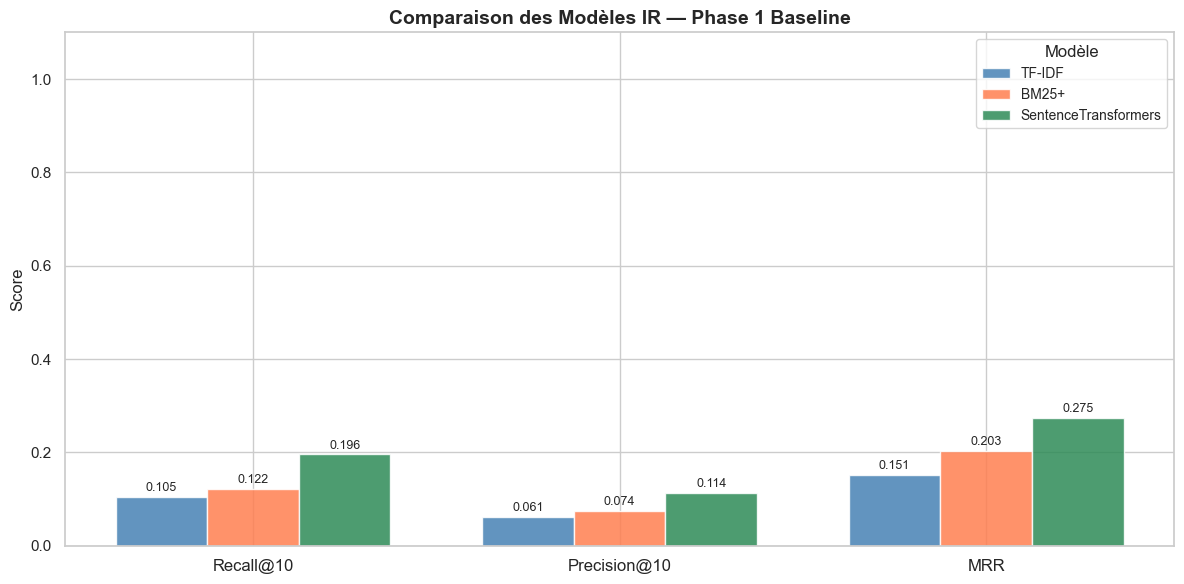

Graphique sauvegardé.


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(df_results.columns))
width  = 0.25
models = df_results.index.tolist()
colors = ['steelblue', 'coral', 'seagreen']

for i, (model, color) in enumerate(zip(models, colors)):
    values = df_results.loc[model].values
    bars   = ax.bar(x + i * width, values, width, label=model, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(df_results.columns, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Modèles IR — Phase 1 Baseline', fontsize=14, fontweight='bold')
ax.legend(title='Modèle', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'baseline_comparison.png'), dpi=150)
plt.show()
print('Graphique sauvegardé.')

## 4. Reconstruction des Modèles pour Analyse Qualitative

In [6]:
# Chargement du corpus
df_docs = pd.read_pickle(os.path.join(DATA_DIR, 'df_docs_preprocessed.pkl'))

with open(os.path.join(DATA_DIR, 'queries_train.json'), 'r', encoding='utf-8') as f:
    queries_train = json.load(f)

with open(os.path.join(DATA_DIR, 'qgts_train.json'), 'r', encoding='utf-8') as f:
    qgts_train = json.load(f)

with open(os.path.join(DATA_DIR, 'queries_test.json'), 'r', encoding='utf-8') as f:
    queries_test = json.load(f)

id_to_idx = {doc_id: idx for idx, doc_id in enumerate(df_docs['id'])}
idx_to_id = {idx: doc_id for doc_id, idx in id_to_idx.items()}

corpus_clean = df_docs['content_clean'].tolist()
corpus_raw   = df_docs['content'].tolist()

def get_relevant_ids(qgts, query_id):
    if query_id not in qgts:
        return []
    return [e['doc_id'] for e in qgts[query_id]['relevant_doc_ids']]

def build_query_text(q):
    parts = [q.get('text', ''), q.get('title', '')]
    if q.get('tags'):
        parts.append(' '.join(q['tags']))
    return ' '.join(p for p in parts if p).strip()

# TF-IDF
with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'tfidf_matrix.pkl'), 'rb') as f:
    tfidf_matrix = pickle.load(f)

# BM25+
with open(os.path.join(MODELS_DIR, 'bm25_index.pkl'), 'rb') as f:
    bm25 = pickle.load(f)

# Sentence Transformers
model_st = SentenceTransformer('all-MiniLM-L6-v2')
corpus_embeddings = np.load(os.path.join(MODELS_DIR, 'corpus_embeddings.npy'))
norms = np.linalg.norm(corpus_embeddings, axis=1, keepdims=True)
corpus_embeddings = corpus_embeddings / np.maximum(norms, 1e-12)

print('Tous les modèles chargés.')

Tous les modèles chargés.


In [7]:
def search_tfidf(query, k=10):
    vec    = vectorizer.transform([query])
    scores = cosine_similarity(vec, tfidf_matrix).flatten()
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}

def search_bm25(query, k=10):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}

def search_embeddings(query, k=10):
    q_emb  = model_st.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores = np.dot(q_emb, corpus_embeddings.T).flatten()
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}

def recall_at_k(retrieved, relevant_ids, k, id_to_idx):
    rel_set = set(id_to_idx[r] for r in relevant_ids if r in id_to_idx)
    ret_set = set(retrieved[:k])
    return len(ret_set & rel_set) / max(len(rel_set), 1)

def mrr(retrieved, relevant_ids, id_to_idx):
    rel_set = set(id_to_idx[r] for r in relevant_ids if r in id_to_idx)
    for rank, idx in enumerate(retrieved, start=1):
        if idx in rel_set:
            return 1.0 / rank
    return 0.0

print('Fonctions de recherche et métriques prêtes.')

Fonctions de recherche et métriques prêtes.


## 5. Analyse Qualitative sur 3 Requêtes Représentatives

In [8]:
# 3 requêtes : facile (termes précis), ambiguë, difficile (paraphrase)
sample_indices = [0, len(queries_train)//3, 2*len(queries_train)//3]
sample_entries = [queries_train[i] for i in sample_indices]
labels = ['Facile', 'Ambiguë', 'Difficile']

search_fns = {
    'TF-IDF':               search_tfidf,
    'BM25+':                search_bm25,
    'SentenceTransformers': search_embeddings
}

for label, q_entry in zip(labels, sample_entries):
    q_text   = build_query_text(q_entry)
    q_id     = q_entry['id']
    relevant = get_relevant_ids(qgts_train, q_id)

    print(f'{"="*70}')
    print(f'[{label}] "{q_text[:75]}"')
    print(f'Docs pertinents : {len(relevant)} | IDs : {relevant[:2]}...')
    print()

    for model_name, fn in search_fns.items():
        result    = fn(q_text, k=5)
        retrieved = result['topk_indices']
        mrr_s     = mrr(retrieved, relevant, id_to_idx)
        rec_s     = recall_at_k(retrieved, relevant, 5, id_to_idx)
        print(f'  [{model_name}] MRR={mrr_s:.3f} | Recall@5={rec_s:.3f}')
        for idx, score in zip(result['topk_indices'][:3], result['topk_scores'][:3]):
            doc_id = idx_to_id[idx]
            marker = '✓' if doc_id in relevant else ' '
            title  = df_docs.iloc[idx]['title'][:50] or df_docs.iloc[idx]['text'][:50]
            print(f"    {marker} [{score:.3f}] {doc_id} — {title}")
    print()

[Facile] "Want to try reformatting Damaged SD Card linux development"
Docs pertinents : 4 | IDs : ['135f5fdb-bcba-40b8-b90d-823617f1e805_21141', 'd0609dab-fbf2-4838-be6a-05e76b291258_30322']...

  [TF-IDF] MRR=0.000 | Recall@5=0.000
      [0.172] 569b7bce-60ab-4ec6-9baa-33dfd9a5489f_87449 — Linux development server
      [0.168] 48ce31f4-a9eb-49df-9e8f-da696b70d124_166481 — Difference between Windows and Linux development e
      [0.148] 18c08039-f948-4702-b217-3a527c39a03f_77319 — Starting Linux Programming
  [BM25+] MRR=0.000 | Recall@5=0.000
      [56.213] 276bf1e2-20da-4758-9009-d2472ad21266_17022 — "USB Storage damaged. It may need reformatting" er
      [51.584] be55a7d5-7935-434c-9425-783681823ef9_40574 — Do you have to reformat an SD Card before you can 
      [51.434] 6260dea3-8a5e-4e28-8c8e-9340f9352887_23121 — How to fix - SD card works intermittently, rest of
  [SentenceTransformers] MRR=0.000 | Recall@5=0.000
      [0.716] 9b7f0646-d400-4843-b5d8-df4ce4cd7b27_7240 — How to

## 6. Synthèse — Forces et Faiblesses

| Modèle | Forces | Faiblesses |
|--------|--------|------------|
| **TF-IDF** | Rapide, simple, explicable. Efficace sur des requêtes exactes avec termes du corpus. | Sensible à la synonymie et polysémie. Pénalise les documents longs. Dépend du preprocessing. |
| **BM25+** | Normalisation par longueur plus fine. Non-zéro pour les termes présents (delta). Paramétrable. | Même problème lexical que TF-IDF. Pas de compréhension sémantique. |
| **SentenceTransformers** | Capture la sémantique et les synonymes. Robuste aux paraphrases. Multilingue possible. | Plus lent à l'encodage. Nécessite GPU pour corpus large. Moins explicable. |

In [9]:
# Affichage final du tableau récapitulatif
print('\n=== TABLEAU RÉCAPITULATIF PHASE 1 ===')
print(df_results.to_string(float_format='{:.4f}'.format))
print()
print('Fichiers produits :')
for f in sorted(os.listdir(OUTPUTS_DIR)):
    print(f'  outputs/{f}')


=== TABLEAU RÉCAPITULATIF PHASE 1 ===
                      Recall@10  Precision@10    MRR
model                                               
TF-IDF                   0.1052        0.0615 0.1514
BM25+                    0.1215        0.0743 0.2034
SentenceTransformers     0.1959        0.1141 0.2745

Fichiers produits :
  outputs/Team_92i_ElMorjen.csv
  outputs/baseline_comparison.png
  outputs/bm25_results.pkl
  outputs/category_distribution.png
  outputs/document_length_distribution.png
  outputs/embedding_viz_tsne.png
  outputs/embedding_viz_umap.png
  outputs/embeddings_results.pkl
  outputs/query_top_words.png
  outputs/submission.csv
  outputs/tfidf_results.pkl
  outputs/top_words.png


## 7. Conclusion Phase 1

La Phase 1 établit une base de comparaison solide avec trois approches complémentaires :

1. **TF-IDF** — référence classique, rapide et interprétable
2. **BM25+** — amélioration de TF-IDF avec meilleure normalisation par longueur
3. **Sentence Transformers** — approche sémantique dense, plus robuste aux variations linguistiques

**Prochaine étape — Phase 2 :**
- Entraîner un classifieur de catégories (M-07)
- Intégrer ce classifieur dans un pipeline de re-ranking (M-08)
- Comparer les résultats Phase 2 vs Phase 1 (M-09)

In [10]:
import csv
from sklearn.linear_model import LogisticRegression

# Choisir le meilleur modèle selon MRR
best_model_name = df_results['MRR'].idxmax()
best_fn = {'TF-IDF': search_tfidf, 'BM25+': search_bm25,
           'SentenceTransformers': search_embeddings}[best_model_name]

print(f'Modèle sélectionné pour la soumission : {best_model_name}')

# Classifieur de catégories (entraîné sur queries_train)
train_texts = [build_query_text(q) for q in queries_train]
train_labels = [q['category'] for q in queries_train]
vectorizer_cat = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words='english'
)
X_train = vectorizer_cat.fit_transform(train_texts)
clf = LogisticRegression(max_iter=2000, n_jobs=1)
clf.fit(X_train, train_labels)

K_SUBMIT = 100  # Kaggle attend généralement top-100
rows = []

for q_entry in queries_test:
    q_id   = q_entry['id']
    q_text = build_query_text(q_entry)

    result   = best_fn(q_text, k=K_SUBMIT)
    doc_ids  = [idx_to_id[idx] for idx in result['topk_indices']]

    q_cat = clf.predict(vectorizer_cat.transform([q_text]))[0]

    rows.append({
        'query_id':         q_id,
        'relevant_doc_ids': json.dumps(doc_ids, ensure_ascii=True),
        'category':         q_cat
    })

submission_path = os.path.join(OUTPUTS_DIR, 'submission.csv')
pd.DataFrame(rows).to_csv(submission_path, index=False)
print(f'Soumission générée : {submission_path}  ({len(rows)} requêtes × top-{K_SUBMIT})')
pd.DataFrame(rows).head(3)

Modèle sélectionné pour la soumission : SentenceTransformers
Soumission générée : ../outputs/submission.csv  (141 requêtes × top-100)


,query_id,relevant_doc_ids,category
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,"[""66e23752-4a83-40b9-a86f-56b00315f908_229423""...",programmers
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,"[""ff80cc70-4393-44de-a57c-e0323838616b_139126""...",unix
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,"[""43fa6e5a-6ad6-4701-ba44-68b513409ffc_17053"",...",android


## 7. Génération de la Soumission Kaggle

Utilise le meilleur modèle Phase 1 pour générer `submission.csv` sur les requêtes de test.

Format attendu : `query_id, relevant_doc_ids, category`